# Transformación de datos: escalado, codificación y discretización

> Cómo convertir las variables limpias en una representación que los modelos puedan usar bien: escalas comparables, distribuciones menos asimétricas, categorías convertidas en números e intervalos cuando conviene.
>
> **Requisitos previos:** [Análisis exploratorio](01-analisis-exploratorio.ipynb), [Limpieza de datos](02-limpieza-datos.ipynb) · **Relacionado:** [Muestreo y desbalanceo](04-muestreo-y-desbalanceo.ipynb)

## 1. Idea clave

Después de limpiar, las variables suelen seguir sin estar listas para un modelo:

- tienen **escalas muy distintas** (edad en años, tarifa en libras), y los métodos basados en distancias o gradientes dan más peso a las de mayor rango;
- algunas son **muy asimétricas**, y unos pocos valores extremos dominan;
- las **categóricas** son texto, y la mayoría de los modelos solo aceptan números;
- a veces interesa agrupar una variable continua en **intervalos** (grupos de edad, niveles de lluvia).

La **transformación de datos** agrupa las técnicas que resuelven estos problemas: **escalado**, **transformaciones no lineales**, **codificación** de categóricas, **discretización** e **ingeniería de atributos**.

Dos reglas guían todo el notebook:
1. Qué transformación hace falta depende del **modelo**: un árbol de decisión no necesita escalado, pero kNN, SVM o la regresión regularizada sí.
2. Toda transformación que aprende algo de los datos (una media, unos cuantiles, unas categorías) se **ajusta solo con el entrenamiento**, idealmente dentro de un `Pipeline`.

## 2. Conceptos importantes

### 2.1. Escalado

Cambia la escala de una variable numérica $x$ sin cambiar la forma de su distribución:

| Método | Fórmula | Resultado | Sensible a atípicos |
|---|---|---|---|
| **Normalización min-max** | $x' = \dfrac{x - x_{\min}}{x_{\max} - x_{\min}}$ | rango $[0, 1]$ | Mucho: un solo extremo comprime el resto |
| **Estandarización** (*z-score*) | $z = \dfrac{x - \bar{x}}{s}$ | media 0, desviación típica 1 | Algo: $\bar{x}$ y $s$ se contaminan |
| **Escalado robusto** | $x' = \dfrac{x - \operatorname{mediana}(x)}{RIC}$ | mediana 0, RIC 1 | Poco |

donde $\bar{x}$ es la media, $s$ la desviación típica y $RIC = Q_3 - Q_1$ el rango intercuartílico.

**Cuándo hace falta:** en métodos basados en **distancias** (kNN, k-means, SVM con núcleo RBF), en los que usan **descenso de gradiente** (redes neuronales), en la regresión **regularizada** (Ridge, Lasso) y en **PCA**, que busca las direcciones de mayor varianza. Los **árboles** y sus conjuntos (random forest, gradient boosting) no lo necesitan: solo comparan valores dentro de cada variable.

### 2.2. Transformaciones no lineales

Cambian la **forma** de la distribución, normalmente para reducir la asimetría:

- **Logaritmo**: $x' = \log(1 + x)$. Comprime la cola derecha. Se suma 1 para que funcione con ceros.
- **Box-Cox**: familia de potencias con un parámetro $\lambda$ que se estima de los datos:

$$
x'(\lambda) = \begin{cases} \dfrac{x^\lambda - 1}{\lambda} & \lambda \neq 0 \\[4pt] \log x & \lambda = 0 \end{cases}
$$

  Solo admite valores **estrictamente positivos**.
- **Yeo-Johnson**: generalización de Box-Cox que admite ceros y negativos.

### 2.3. Codificación de variables categóricas

| Método | Cómo funciona | Para |
|---|---|---|
| **One-hot** | Una columna binaria (0/1) por categoría | Nominales (sin orden) |
| **Ordinal** | Un entero por categoría, **en el orden que definimos** | Ordinales (con orden) |
| **Por la objetivo** (*target encoding*) | Cada categoría se sustituye por la media de la objetivo en esa categoría | Nominales con muchas categorías |

- **One-hot** no inventa ningún orden, pero con muchas categorías (**alta cardinalidad**) genera muchas columnas casi vacías. Las categorías raras se pueden agrupar en una sola "otras".
- **Ordinal** con un orden arbitrario (alfabético, por ejemplo) introduce relaciones falsas: el modelo creerá que "C" está entre "B" y "D".
- **Por la objetivo** usa `y`, así que hay riesgo de fuga de datos. Se calcula con validación cruzada interna, como hace `TargetEncoder` de scikit-learn.

### 2.4. Discretización

Convierte una variable continua en categorías (intervalos o *bins*). Puede hacer los modelos más interpretables y más robustos al ruido y a los atípicos, pero **siempre pierde información**.

**No supervisados** (no usan la variable objetivo). Con $k$ intervalos:
- **Igual amplitud** (*equal width*): todos los intervalos miden lo mismo, $\alpha = \dfrac{x_{\max} - x_{\min}}{k}$. Con variables asimétricas, casi todos los datos caen en el primer intervalo.
- **Igual frecuencia** (*equal frequency*): cada intervalo contiene aproximadamente $n/k$ observaciones. Los cortes son los cuantiles.
- **Por agrupamiento** (*k-means*): los cortes separan grupos naturales de valores.

**Supervisados** (usan la objetivo para elegir los cortes):
- **Basados en entropía**: eligen el corte que deja los intervalos más "puros" respecto a la clase, es decir, con menor entropía $H = -\sum_c p_c \log_2 p_c$, donde $p_c$ es la proporción de la clase $c$ en el intervalo. Es lo que hace un árbol de decisión en cada división.
- **ChiMerge**: parte de intervalos pequeños y fusiona los adyacentes cuando un contraste $\chi^2$ indica que tienen distribuciones de clase parecidas.

**Por conocimiento del dominio**: cortes con significado (0–12 años = niño; lluvia débil < 2 mm). Suelen ser los más interpretables.

### 2.5. Ingeniería de atributos

La **ingeniería de atributos** (*feature engineering*) crea variables nuevas a partir de las existentes usando conocimiento del problema. El ejemplo clásico es el índice de masa corporal: peso / altura², que dice más que las dos variables por separado. A menudo aporta más que cambiar de modelo.

## 3. Código

Usamos otra vez el conjunto **Titanic** de `seaborn`. Es una versión preprocesada por seaborn de los datos de la competición *Titanic* de Kaggle: se han quitado las columnas que identifican al pasajero (id, nombre, billete, camarote) y se han añadido columnas derivadas (`class`, `who`, `alive`…). La variable objetivo es `survived`.

### 3.1. Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer, LabelEncoder, MinMaxScaler, OneHotEncoder,
    OrdinalEncoder, PowerTransformer, RobustScaler, StandardScaler,
)
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", 20)

In [2]:
df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "class", "sex", "age", "sibsp", "parch", "fare", "embarked", "deck"]]

y = df["survived"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

df.head()

,survived,pclass,class,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,Third,male,22.0,1,0,7.2500,S,NaN
1,1,1,First,female,38.0,1,0,71.2833,C,C
2,1,3,Third,female,26.0,0,0,7.9250,S,NaN
3,1,1,First,female,35.0,1,0,53.1000,S,C
4,0,3,Third,male,35.0,0,0,8.0500,S,NaN


### 3.2. Escalado

Los tres escaladores aplicados a la tarifa (`fare`), que tiene atípicos:

In [3]:
fare = df[["fare"]]
escalados = pd.DataFrame({
    "original": fare["fare"],
    "min-max": MinMaxScaler().fit_transform(fare).ravel(),
    "z-score": StandardScaler().fit_transform(fare).ravel(),
    "robusto": RobustScaler().fit_transform(fare).ravel(),
})
escalados.describe().loc[["mean", "50%", "std", "min", "max"]].round(2)

,original,min-max,z-score,robusto
mean,32.20,0.06,0.00,0.77
50%,14.45,0.03,-0.36,0.00
std,49.69,0.10,1.00,2.15
min,0.00,0.00,-0.65,-0.63
max,512.33,1.00,9.67,21.56


- Con **min-max**, el billete de 512 libras fija el máximo en 1. La mediana queda en 0,03: casi todos los pasajeros se aplastan cerca de 0.
- Con **z-score**, la media es 0 y la desviación típica 1, pero el máximo queda a casi 10 desviaciones.
- El **escalado robusto** centra en la mediana (0) y usa el RIC. El centro de la distribución queda bien repartido, aunque los extremos siguen siendo extremos: escalar **no elimina los atípicos**.

**¿Por qué importa?** kNN clasifica por distancias. Sin escalar, la tarifa (0–512) domina sobre el número de hermanos (0–8) o el sexo (0/1). Comparamos el mismo modelo con y sin escalado, con validación cruzada y todo dentro de un `Pipeline`:

In [4]:
X_num = df[["pclass", "age", "sibsp", "parch", "fare"]].assign(sex=(df["sex"] == "female").astype(int))

sin_escalar = make_pipeline(SimpleImputer(strategy="median"), KNeighborsClassifier())
con_escalado = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), KNeighborsClassifier())

for nombre, modelo in [("kNN sin escalar", sin_escalar), ("kNN con escalado", con_escalado)]:
    print(f"{nombre}: {cross_val_score(modelo, X_num, y, cv=cv).mean():.3f}")

kNN sin escalar: 0.712
kNN con escalado: 0.824


Solo por escalar, la exactitud media pasa del 71 % al 82 %.

### 3.3. Transformaciones no lineales

La tarifa es muy asimétrica (asimetría 4,79, ver el [análisis exploratorio](01-analisis-exploratorio.ipynb)). Comparamos el logaritmo y Yeo-Johnson:

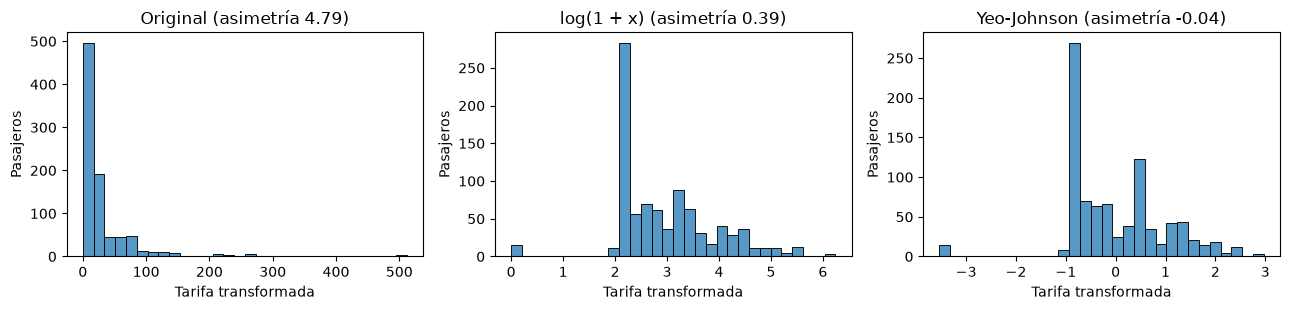

In [5]:
fare_log = np.log1p(df["fare"])
fare_yj = pd.Series(PowerTransformer(method="yeo-johnson").fit_transform(fare).ravel())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (nombre, serie) in zip(axes, [("Original", df["fare"]),
                                       ("log(1 + x)", fare_log),
                                       ("Yeo-Johnson", fare_yj)]):
    sns.histplot(serie, bins=30, ax=ax)
    ax.set_title(f"{nombre} (asimetría {serie.skew():.2f})")
    ax.set_xlabel("Tarifa transformada")
    ax.set_ylabel("Pasajeros")
plt.tight_layout()
plt.show()

El logaritmo baja la asimetría de 4,79 a 0,39, y Yeo-Johnson casi la elimina (−0,04). Eso no significa que la distribución se vuelva normal: sigue el pico de las tarifas de 3.ª clase (unas 8 libras), y los 15 billetes de 0 libras quedan aislados a la izquierda. Esos ceros merecen revisarse en la [limpieza](02-limpieza-datos.ipynb): ¿billetes gratuitos o datos que faltan?

¿Y Box-Cox? La tarifa tiene **15 billetes de 0 libras**, y Box-Cox solo admite valores estrictamente positivos:

In [6]:
print(f"Tarifas iguales a 0: {(df['fare'] == 0).sum()}")
try:
    PowerTransformer(method="box-cox").fit(fare)
except ValueError as error:
    print(f"Box-Cox falla: {error}")

Tarifas iguales a 0: 15
Box-Cox falla: The Box-Cox transformation can only be applied to strictly positive data


### 3.4. Codificación de variables categóricas

**One-hot** para las nominales. `OneHotEncoder` recuerda las categorías vistas en el entrenamiento. Con `handle_unknown="ignore"`, una categoría nueva no rompe el modelo en producción. Con `min_frequency`, las categorías raras se agrupan en una columna `infrequent`:

In [7]:
print(df["deck"].value_counts().to_dict())

ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False)
cubierta = df[["deck"]].astype(object).fillna("Desconocida")
codificada = ohe.fit_transform(cubierta)

print(ohe.get_feature_names_out())
print(codificada.shape)

{'C': 59, 'B': 47, 'D': 33, 'E': 32, 'A': 15, 'F': 13, 'G': 4}
['deck_A' 'deck_B' 'deck_C' 'deck_D' 'deck_Desconocida' 'deck_E' 'deck_F'
 'deck_infrequent_sklearn']
(891, 8)


La cubierta `G` (4 pasajeros) pasa a `deck_infrequent_sklearn` en lugar de tener columna propia. Los perdidos se han codificado como una categoría más, `Desconocida`, porque la ausencia es informativa (ver [limpieza de datos](02-limpieza-datos.ipynb#3.9.-Imputación)).

**Ordinal** para las que tienen orden. Hay que dar el orden **explícitamente**:

In [8]:
ordinal = OrdinalEncoder(categories=[["Third", "Second", "First"]])
df_ord = df[["class"]].astype(object)
pd.DataFrame({
    "class": df_ord["class"],
    "codificada": ordinal.fit_transform(df_ord).ravel(),
}).drop_duplicates().sort_values("codificada")

,class,codificada
0,Third,0.0
9,Second,1.0
1,First,2.0


Así, 3.ª clase = 0 < 2.ª = 1 < 1.ª = 2, que respeta el orden real. Sin `categories`, el orden sería alfabético.

### 3.5. Discretización

**No supervisada.** Tres estrategias de `KBinsDiscretizer` sobre la tarifa, con 4 intervalos:

In [9]:
filas = []
for estrategia in ["uniform", "quantile", "kmeans"]:
    extra = {"quantile_method": "averaged_inverted_cdf"} if estrategia == "quantile" else {}
    kbd = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy=estrategia, random_state=42, **extra)
    intervalos = kbd.fit_transform(fare).ravel()
    filas.append({
        "estrategia": estrategia,
        "cortes": np.round(kbd.bin_edges_[0][1:-1], 1).tolist(),
        "pasajeros por intervalo": np.bincount(intervalos.astype(int)).tolist(),
    })
pd.DataFrame(filas)

,estrategia,cortes,pasajeros por intervalo
0,uniform,"[128.1, 256.2, 384.2]","[853, 29, 6, 3]"
1,quantile,"[7.9, 14.5, 31.0]","[185, 255, 226, 225]"
2,kmeans,"[48.6, 156.1, 371.4]","[727, 142, 19, 3]"


- **Igual amplitud** (`uniform`) corta cada 128 libras: **853 de 891** pasajeros caen en el primer intervalo, y la variable queda casi inservible.
- **Igual frecuencia** (`quantile`) corta en los cuartiles (7,9 / 14,5 / 31). Los grupos no son exactamente iguales (185 frente a 255) porque muchos pasajeros pagaron la misma tarifa, y un valor repetido no se puede partir entre dos intervalos.
- **k-means** busca grupos naturales y queda en medio.

**Por dominio.** Para la edad hay cortes con significado:

In [10]:
grupo_edad = pd.cut(df["age"], bins=[0, 12, 18, 60, np.inf],
                    labels=["niño", "adolescente", "adulto", "mayor"], right=False)
df.groupby(grupo_edad, observed=True)["survived"].agg(["mean", "size"]).round(2)

,mean,size
age,,
niño,0.57,68
adolescente,0.49,45
adulto,0.39,575
mayor,0.27,26


**Supervisada (basada en entropía).** Un árbol de decisión pequeño, entrenado solo con la edad, elige los cortes que mejor separan a supervivientes y fallecidos:

In [11]:
edad = df[["age", "survived"]].dropna()
arbol = DecisionTreeClassifier(criterion="entropy", max_leaf_nodes=4, random_state=42)
arbol.fit(edad[["age"]], edad["survived"])

cortes = sorted(t for t in arbol.tree_.threshold if t != -2)  # -2 marca las hojas
print(f"Cortes elegidos por el árbol: {np.round(cortes, 1).tolist()}")

Cortes elegidos por el árbol: [6.5, 63.5, 77.0]


El primer corte, en **6,5 años**, coincide con lo que el EDA ya sugería: los niños pequeños sobrevivieron mucho más. Los otros dos separan a unos pocos pasajeros mayores. Con más intervalos, el árbol acabaría ajustándose al ruido.

### 3.6. Ingeniería de atributos

`sibsp` (hermanos y cónyuge) y `parch` (padres e hijos) tienen más sentido juntas, como **tamaño de la familia**:

In [12]:
familia = (df["sibsp"] + df["parch"] + 1).rename("tamano_familia")
tipo_familia = pd.cut(familia, bins=[0, 1, 4, np.inf], labels=["solo", "pequeña (2-4)", "grande (5+)"])
df.groupby(tipo_familia, observed=True)["survived"].agg(["mean", "size"]).round(2)

,mean,size
tamano_familia,,
solo,0.30,537
pequeña (2-4),0.58,292
grande (5+),0.16,62


La relación no es lineal: las familias pequeñas sobrevivieron más que quienes viajaban solos, y las grandes mucho menos. Ni `sibsp` ni `parch` por separado lo mostraban con tanta claridad.

### 3.7. Todo junto: `ColumnTransformer` + `Pipeline`

En un proyecto real, cada tipo de columna recibe su transformación, y todo se encadena con el modelo. Así, en cada partición de la validación cruzada, las medianas, las escalas y las categorías se aprenden **solo con el entrenamiento**:

In [13]:
X = df.drop(columns=["survived", "pclass"]).assign(
    tamano_familia=df["sibsp"] + df["parch"] + 1,
    deck=df["deck"].astype(object),
    **{"class": df["class"].astype(object)},
)

numericas = ["age", "sibsp", "parch", "tamano_familia"]
asimetricas = ["fare"]
nominales = ["sex", "embarked", "deck"]
ordinales = ["class"]

preprocesado = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numericas),
    ("asim", make_pipeline(PowerTransformer(method="yeo-johnson")), asimetricas),
    ("nom", make_pipeline(SimpleImputer(strategy="constant", fill_value="Desconocida"),
                          OneHotEncoder(handle_unknown="ignore", min_frequency=10)), nominales),
    ("ord", OrdinalEncoder(categories=[["Third", "Second", "First"]]), ordinales),
])

modelo = make_pipeline(preprocesado, LogisticRegression(max_iter=1000))
print(f"Exactitud media (validación cruzada): {cross_val_score(modelo, X, y, cv=cv).mean():.3f}")

# Columnas que ve el modelo tras el preprocesado
modelo.fit(X, y)
print(len(modelo[0].get_feature_names_out()), "columnas:", modelo[0].get_feature_names_out()[:6], "...")

Exactitud media (validación cruzada): 0.794
20 columnas: ['num__age' 'num__sibsp' 'num__parch' 'num__tamano_familia' 'asim__fare'
 'nom__sex_female'] ...


La exactitud (79 %) es algo menor que la del kNN escalado de 3.2 (82 %). El objetivo de este apartado no es optimizar el modelo: es mostrar el **esquema** que evita la fuga de datos y aplica a cada columna la transformación que le corresponde.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase / función | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `MinMaxScaler` | `feature_range` | Rango de salida | `(0, 1)` por defecto; `(-1, 1)` para algunas redes |
| `RobustScaler` | `quantile_range` | Qué rango se usa como escala | `(25, 75)` = RIC |
| `PowerTransformer` | `method` | `"yeo-johnson"` o `"box-cox"` | Box-Cox solo con valores > 0 |
| | `standardize` | Si además estandariza el resultado | `True` por defecto |
| `OneHotEncoder` | `handle_unknown` | Qué hacer con categorías nuevas | `"ignore"` (o `"infrequent_if_exist"`) para no fallar en producción |
| | `min_frequency`, `max_categories` | Agrupar categorías raras | Imprescindible con alta cardinalidad |
| | `drop` | Quitar una columna por variable | `"first"` evita la colinealidad perfecta en regresión lineal sin regularizar |
| `OrdinalEncoder` | `categories` | Orden de las categorías | Dalo **siempre** explícito en variables ordinales |
| `KBinsDiscretizer` | `strategy` | `uniform`, `quantile` o `kmeans` | `quantile` con variables asimétricas |
| | `n_bins` | Número de intervalos | Pocos pierden información; muchos, casi vacíos |
| | `encode` | `"onehot"` u `"ordinal"` | `"ordinal"` para inspeccionar; `"onehot"` para modelos lineales |
| `pd.cut` / `pd.qcut` | `bins` / `q`, `right` | Cortes fijos o por cuantiles, y qué extremo es cerrado | Revisa los extremos: un valor justo en el corte puede cambiar de grupo |

### 4.2. Errores comunes

Varias de estas lecciones salen de un análisis real de accidentes de tráfico cruzado con datos meteorológicos diarios, donde la precipitación diaria (en mm) se discretizó en cinco niveles: sin lluvia, débil, moderada, fuerte y muy fuerte.

**1. Usar `LabelEncoder` con variables de entrada.** `LabelEncoder` está pensado para la **variable objetivo** (`y`) y ordena las categorías **alfabéticamente**. Aplicado a los niveles de lluvia, daba "fuerte" = 1 < "moderada" = 2, y "sin lluvia" = 4, el valor más alto:

In [14]:
lluvia = pd.Series(["No lluvia", "Lluvia débil", "Lluvia moderada", "Lluvia fuerte", "Lluvia muy fuerte"])
le = LabelEncoder().fit(lluvia)
{categoria: int(codigo) for categoria, codigo in zip(le.classes_, le.transform(le.classes_))}

{'Lluvia débil': 0,
 'Lluvia fuerte': 1,
 'Lluvia moderada': 2,
 'Lluvia muy fuerte': 3,
 'No lluvia': 4}

Para variables de entrada ordinales, usa `OrdinalEncoder` con el orden explícito (o un `Categorical` ordenado de pandas).

**2. Olvidar una categoría al definir el orden.** Al corregir el problema anterior con `pd.Categorical(..., categories=orden, ordered=True)`, la lista de orden no incluía "Lluvia muy fuerte". Pandas convirtió esos valores en `NaN`, y `.cat.codes` les asignó el código **−1**, sin error. En los datos reales, los **9 días** de lluvia muy fuerte (más de 30 mm) quedaron codificados como −1, es decir, "por debajo de sin lluvia":

In [15]:
orden_incompleto = ["No lluvia", "Lluvia débil", "Lluvia moderada", "Lluvia fuerte"]
# Equivalente a pd.Categorical(lluvia, categories=orden_incompleto, ordered=True).codes
codigos = lluvia.map({c: i for i, c in enumerate(orden_incompleto)}).fillna(-1).astype(int)
print(dict(zip(lluvia, codigos)))  # -1 = categoría no incluida en el orden

# OrdinalEncoder, en cambio, avisa con un error
try:
    OrdinalEncoder(categories=[orden_incompleto]).fit(lluvia.to_frame())
except ValueError as error:
    print(f"OrdinalEncoder: {error}")

{'No lluvia': 0, 'Lluvia débil': 1, 'Lluvia moderada': 2, 'Lluvia fuerte': 3, 'Lluvia muy fuerte': -1}
OrdinalEncoder: Found unknown categories ['Lluvia muy fuerte'] in column 0 during fit


Comprueba siempre que no quedan `NaN` ni códigos −1 después de codificar.

**3. Llamar "igual amplitud" a cualquier discretización (y confundirla con igual frecuencia).** Los cortes de la lluvia (0, 2, 15, 30 mm y más) se describieron como de igual amplitud, pero son **cortes de dominio**, y con buen criterio: el 76 % de los días no llovía, así que "sin lluvia" se trató como categoría propia. Igual amplitud significa intervalos de **la misma longitud**; igual frecuencia, intervalos con **el mismo número de observaciones**. Hay textos que confunden las dos definiciones. En 3.5 se ve la diferencia: en la tarifa, una deja 853 pasajeros en un solo intervalo y la otra los reparte.

**4. Ajustar el escalado con todos los datos antes de dividir.** Estandarizar el conjunto completo y después separar entrenamiento y prueba hace que la media y la desviación típica incluyan información del conjunto de prueba (fuga de datos). Con escaladores el efecto suele ser pequeño, pero con transformaciones que aprenden más (cuantiles, codificación por la objetivo, imputación kNN) puede ser grande. La solución es la de 3.7: todo dentro de un `Pipeline`.

**5. One-hot con muchas categorías raras.** El tipo de vía del accidente tenía 23 categorías, 8 de ellas con menos de 10 casos. Una columna por categoría da columnas casi vacías, que añaden ruido y riesgo de sobreajuste. Agrupa las raras (`min_frequency`, `max_categories`), usa conocimiento del dominio para fusionarlas o prueba la codificación por la objetivo.

**6. Aplicar Box-Cox sin mirar el mínimo.** Cualquier cero o negativo lo hace fallar (3.3). Usa Yeo-Johnson, o $\log(1 + x)$ si solo hay ceros.

**7. Escalar "por si acaso" o discretizar sin motivo.** Los árboles no ganan nada con el escalado, y discretizar siempre pierde información: una edad de 11,9 y una de 12,1 acaban en grupos distintos, mientras que una de 12,1 y una de 59 comparten grupo. Transforma cuando el modelo o la interpretación lo pidan.

## 5. Comparación con métodos relacionados

### 5.1. Escalado y transformaciones

| Técnica | Cambia la forma | Robusta a atípicos | Cuándo usarla |
|---|---|---|---|
| Min-max | No | No | Variables acotadas sin atípicos; redes con entradas en [0, 1] |
| Z-score | No | Poco | Opción por defecto para kNN, SVM, PCA y modelos regularizados |
| Robusto (mediana/RIC) | No | Sí | Variables con atípicos que se quieren conservar |
| $\log(1 + x)$ | Sí | Sí (comprime la cola) | Recuentos y cantidades positivas con cola derecha |
| Box-Cox | Sí | Sí | Solo valores > 0; busca la potencia óptima |
| Yeo-Johnson | Sí | Sí | Como Box-Cox, pero admite ceros y negativos |

### 5.2. Codificación de categóricas

| Técnica | Columnas que genera | Introduce orden | Riesgo | Cuándo usarla |
|---|---|---|---|---|
| One-hot | Una por categoría | No | Explosión de columnas | Nominales con pocas categorías |
| One-hot con agrupación | Una por categoría frecuente + "otras" | No | Pierde el detalle de las raras | Nominales con categorías raras |
| Ordinal (orden explícito) | Una | Sí (el correcto) | Supone distancias iguales entre niveles | Ordinales |
| Por la objetivo | Una | No | Fuga de datos si no se hace con validación cruzada | Alta cardinalidad |
| `LabelEncoder` | Una | Sí (alfabético) | Orden falso | **Solo** la variable objetivo |

### 5.3. Discretización

| Método | Usa la objetivo | Ventaja | Inconveniente |
|---|---|---|---|
| Igual amplitud | No | Cortes fáciles de leer | Con asimetría, casi todo cae en un intervalo |
| Igual frecuencia | No | Intervalos equilibrados | Cortes poco interpretables; valores repetidos |
| k-means | No | Respeta grupos naturales | Depende de la inicialización |
| Entropía (árbol) / ChiMerge | Sí | Cortes útiles para predecir | Riesgo de sobreajuste; hay que validarlos |
| Por dominio | No | Máxima interpretabilidad | Requiere conocer el problema |

## 6. Referencias

### Fuentes

- scikit-learn: [*Preprocessing data*](https://scikit-learn.org/stable/modules/preprocessing.html) (escaladores, `PowerTransformer`, codificadores y `KBinsDiscretizer`), [*ColumnTransformer for heterogeneous data*](https://scikit-learn.org/stable/modules/compose.html#columntransformer-for-heterogeneous-data) y [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).
- pandas: [`cut`](https://pandas.pydata.org/docs/reference/api/pandas.cut.html) y [*Categorical data*](https://pandas.pydata.org/docs/user_guide/categorical.html).
- Dataset: [`titanic.csv` en seaborn-data](https://github.com/mwaskom/seaborn-data), versión adaptada de los datos de la competición [*Titanic* de Kaggle](https://www.kaggle.com/c/titanic/data).

### Para saber más

- Zheng, A. y Casari, A. (2018). *Feature Engineering for Machine Learning*. O'Reilly. Escalado, transformaciones, discretización y codificación con ejemplos en Python.
- Kuhn, M. y Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press. Referencia más profunda sobre cómo representar las variables para los modelos; tiene [versión web abierta](https://bookdown.org/max/FES).